# Get measured capacity and resistance for each formation protocol

2025/04/30

Andrew Weng

In [2]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from src import ioutils as ioutils
from src import simutils as simutils
from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

%load_ext autoreload
%matplotlib widget
plotter.initialize(plt)

target_dir = os.getcwd()

# Load the experimental data

In [3]:
expt1, df1 = ioutils.fetch_experimental_data(152064, to_include_cycling=True)
# expt2, df2 = ioutils.fetch_experimental_data(152074)
expt3, df3 = ioutils.fetch_experimental_data(152071, to_include_cycling=True)
expt4, df4 = ioutils.fetch_experimental_data(152098, to_include_cycling=True)

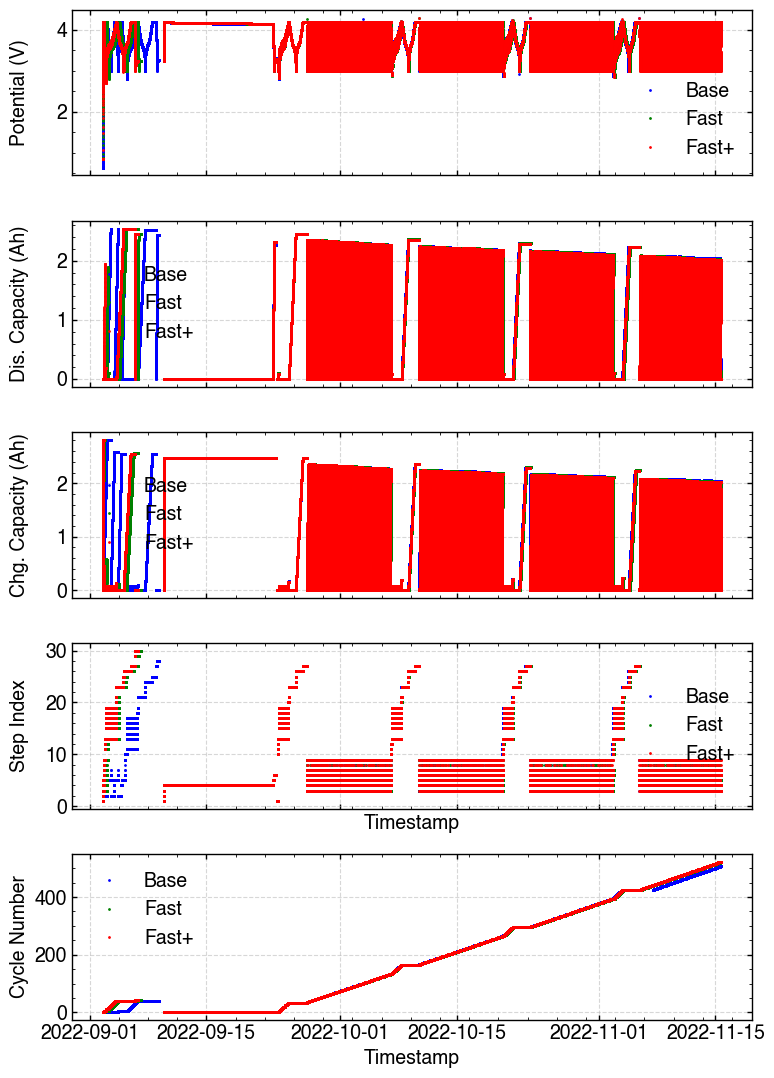

In [3]:
%matplotlib inline

fig, axs = plt.subplots(5, 1, figsize=(8, 11), sharex=True)

# First subplot
axs[0].plot(df1['Timestamp'], df1['Potential (V)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[0].plot(df3['Timestamp'], df3['Potential (V)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[0].plot(df4['Timestamp'], df4['Potential (V)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[0].set_ylabel('Potential (V)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

# Second subplot
axs[1].plot(df1['Timestamp'], df1['Discharge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[1].plot(df3['Timestamp'], df3['Discharge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[1].plot(df4['Timestamp'], df4['Discharge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[1].set_ylabel('Dis. Capacity (Ah)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

# Third subplot
axs[2].plot(df1['Timestamp'], df1['Charge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[2].plot(df3['Timestamp'], df3['Charge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[2].plot(df4['Timestamp'], df4['Charge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[2].set_ylabel('Chg. Capacity (Ah)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend()

# Fourth subplot
axs[3].plot(df1['Timestamp'], df1['Step Index'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[3].plot(df3['Timestamp'], df3['Step Index'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[3].plot(df4['Timestamp'], df4['Step Index'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[3].set_ylabel('Step Index')
axs[3].set_xlabel('Timestamp')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend()

# Fifth suplot (Cycle Number)
axs[4].plot(df1['Timestamp'], df1['Cycle Number'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[4].plot(df3['Timestamp'], df3['Cycle Number'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[4].plot(df4['Timestamp'], df4['Cycle Number'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[4].legend()
axs[4].set_ylabel('Cycle Number')
axs[4].set_xlabel('Timestamp')
axs[4].grid(True, linestyle='--', alpha=0.5)


# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()

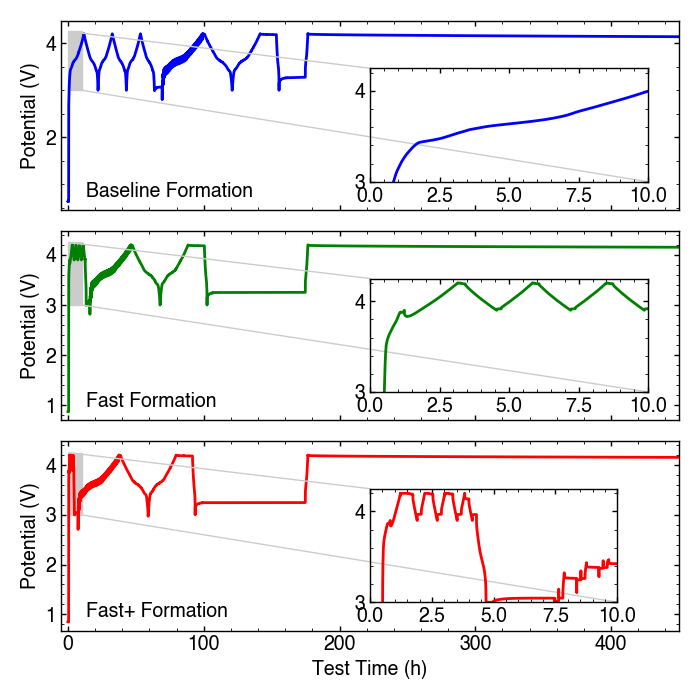

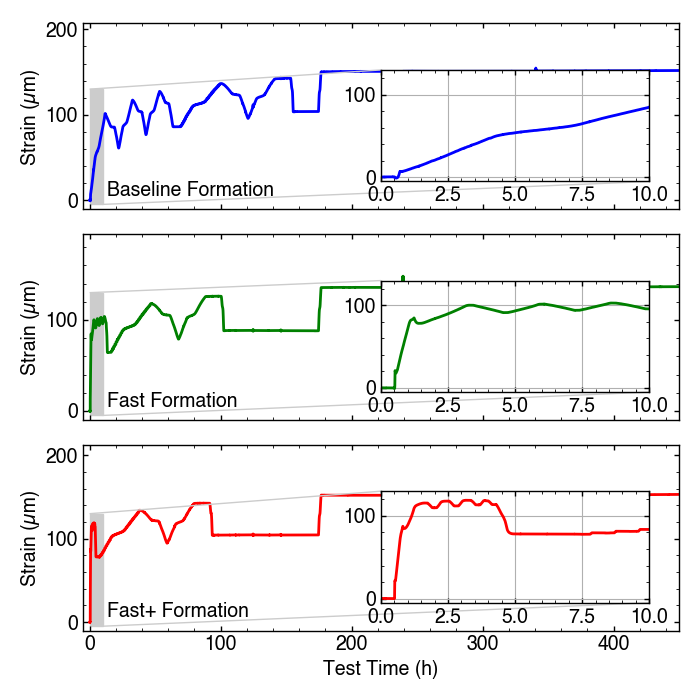

In [4]:
FIGSIZE = (7, 7)
fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True)

axs[0].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], label='Baseline Formation', color='blue', ls='-')
axs[0].set_ylabel('Potential (V)')
axs[0].grid(False)
axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')

axs[1].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], label='Fast Formation', color='green', ls='-')
axs[1].set_ylabel('Potential (V)')
axs[1].grid(False)
axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')

axs[2].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], label='Fast+ Formation', color='red', ls='-')
axs[2].set_ylabel('Potential (V)')
axs[2].grid(False)
axs[2].set_xlim((-5, 450))
axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')

# Create insets for each subplot
axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
axins3 = axs[2].inset_axes([0.50, 0.15, 0.4, 0.6])

# Plot the zoomed regions
axins1.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='blue')
axins2.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='green')
axins3.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='red')

# Set the limits for the zoomed region (first 10 hours)
for axins in [axins1, axins2, axins3]:
    axins.set_xlim(0, 10)
    axins.set_ylim(3, 4.25)
    axins.grid(False)

# Mark the inset regions
mark_inset(axs[0], axins1, loc1=2, loc2=4, fc="0.8", ec="0.8")
mark_inset(axs[1], axins2, loc1=2, loc2=4, fc="0.8", ec="0.8")
mark_inset(axs[2], axins3, loc1=2, loc2=4, fc="0.8", ec="0.8")

axs[2].set_xlabel('Test Time (h)')
# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig('experimental_voltage.svg', format='svg', dpi=300)
plt.show()

fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True)

axs[0].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Baseline formation', color='blue', ls='-', marker='', markersize=1)
axs[0].set_ylabel('Strain (µm)')
axs[0].grid(False)
axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')

axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast Formation', color='green', ls='-', marker='', markersize=1)
axs[1].set_ylabel('Strain (µm)')
axs[1].grid(False)
axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')

axs[2].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+ Formation', color='red', ls='-', marker='', markersize=1)
axs[2].set_ylabel('Strain (µm)')
axs[2].grid(False)
axs[2].set_xlim((-5, 450))
axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')

# Create insets for each subplot
axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
axins3 = axs[2].inset_axes([0.50, 0.15, 0.45, 0.6])

# Plot the zoomed regions
axins1.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='blue')
axins2.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='green')
axins3.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='red')

# Set the limits for the zoomed region (first 10 hours)
for axins in [axins1, axins2, axins3]:
    axins.set_xlim(0, 10)
    axins.set_ylim(-5, 130)
    axins.grid(True)

# Mark the inset regions
mark_inset(axs[0], axins1, loc1=2, loc2=4, fc="0.8", ec="0.8")
mark_inset(axs[1], axins2, loc1=2, loc2=4, fc="0.8", ec="0.8")
mark_inset(axs[2], axins3, loc1=2, loc2=4, fc="0.8", ec="0.8")

# axs[1].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Base', color='blue', ls='', marker='o', markersize=1)
# axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast', color='green', ls='', marker='o', markersize=1)
# axs[1].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+', color='red', ls='', marker='o', markersize=1)
# axs[1].set_ylabel('Strain (um)')
# axs[1].legend()

axs[2].set_xlabel('Test Time (h)')
# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig('experimental_strain.svg', format='svg', dpi=300)
plt.show()

In [6]:
# d_ec_opt = 2.84e-20
# d_vc_opt = 5.39e-14
gamma_kappa = 3367

d_vc_opt = 6.14664e-14
d_ec_opt = 4.5185e-20

# df_sim1 = run_sim('base', d_ec_opt, d_vc_opt, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp1)
# df_sim2 = run_sim('fast', d_ec_opt, d_vc_opt, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp3)
# df_sim3 = run_sim('fast+', d_ec_opt, d_vc_opt, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp4)

# With optimal d_ec and d_vc values
df_sim1 = simutils.run_sim('base', 3.2e-20, 4.2e-16, gamma_kappa, dt=5, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)
df_sim2 = simutils.run_sim('fast', 3.2e-20, 3.2e-17, gamma_kappa, dt=5, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)
df_sim3 = simutils.run_sim('fast+', 5.1e-20, 3.2e-17, gamma_kappa, dt=1, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)

# With baseline d_ec and d_vc values
# df_sim1 = simutils.run_sim('base', 3.2e-20, 4.2e-16, gamma_kappa, dt=5, to_follow_current=False, to_simulate_form_aging=True)
# df_sim2 = simutils.run_sim('fast', 3.2e-20, 4.2e-16, gamma_kappa, dt=5, to_follow_current=False, to_simulate_form_aging=True)
# df_sim3 = simutils.run_sim('fast+', 3.2e-20, 4.2e-16, gamma_kappa, dt=1, to_follow_current=False, to_simulate_form_aging=True)



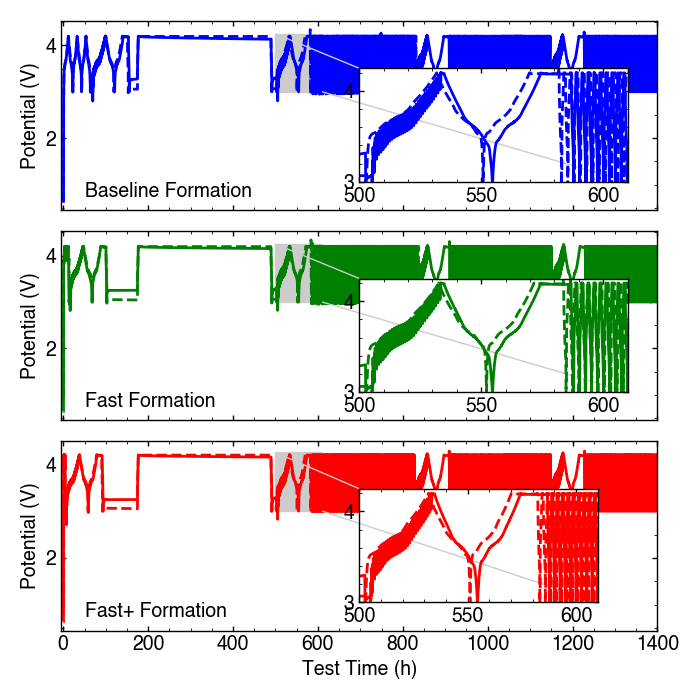

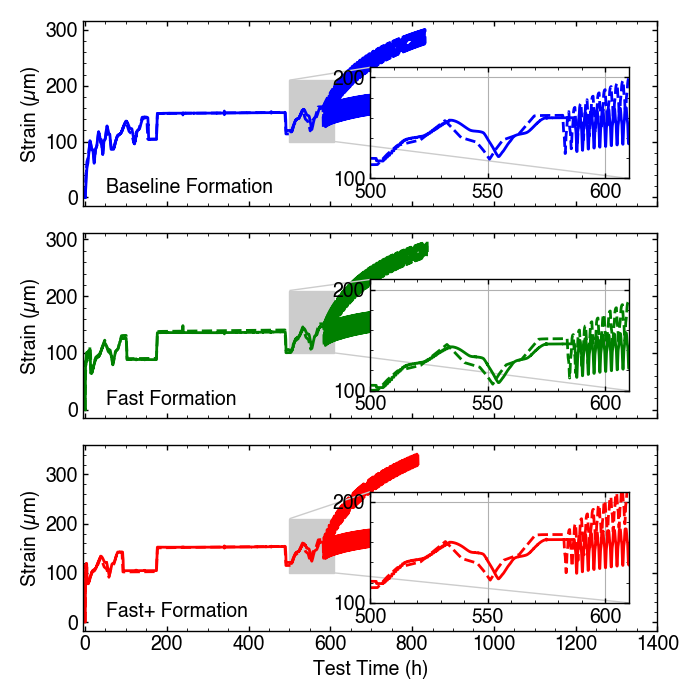

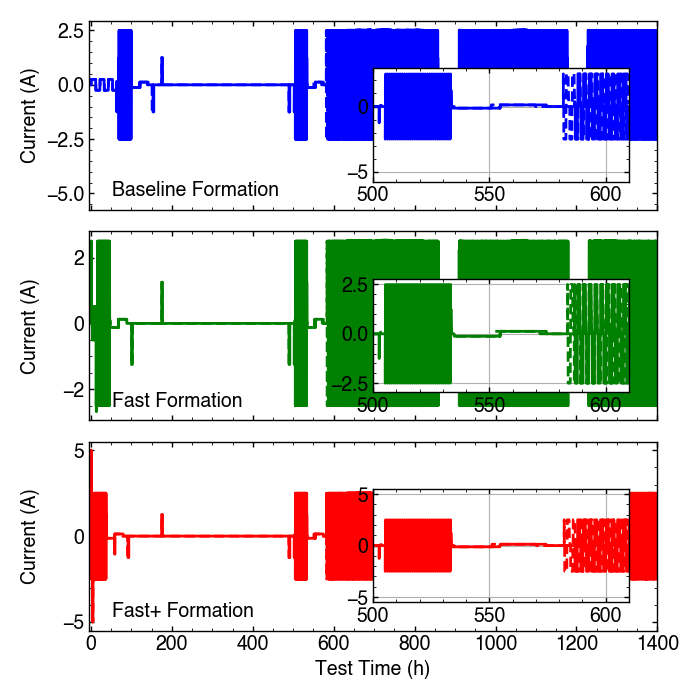

In [7]:
%matplotlib widget 

INCLUDE_INSET = True

XLIM_INSET = (500, 610)
XMAX = 1400;
FIGSIZE = (7, 7)

## VOLTAGE PLOTS
fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True)

axs[0].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], label='Baseline Formation', color='blue', ls='-')
axs[0].plot(df_sim1['t']/3600, df_sim1['vt'], label='', color='blue', ls='--')
axs[0].set_ylabel('Potential (V)')
axs[0].grid(False)
axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')

axs[1].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], label='Fast Formation', color='green', ls='-')
axs[1].plot(df_sim2['t']/3600, df_sim2['vt'], label='', color='green', ls='--')
axs[1].set_ylabel('Potential (V)')
axs[1].grid(False)
axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')

axs[2].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], label='Fast+ Formation', color='red', ls='-')
axs[2].plot(df_sim3['t']/3600, df_sim3['vt'], label='', color='red', ls='--')
axs[2].set_ylabel('Potential (V)')
axs[2].grid(False)
axs[2].set_xlim((-5, XMAX))
axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')

if INCLUDE_INSET:
    # Create insets for each subplot
    axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
    axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
    axins3 = axs[2].inset_axes([0.50, 0.15, 0.4, 0.6])

    # Plot the zoomed regions
    axins1.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='blue')
    axins1.plot(df_sim1['t']/3600, df_sim1['vt'], color='blue', ls='--')
    axins2.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='green')
    axins2.plot(df_sim2['t']/3600, df_sim2['vt'], color='green', ls='--')
    axins3.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='red')
    axins3.plot(df_sim3['t']/3600, df_sim3['vt'], color='red', ls='--')

    # Set the limits for the zoomed region (first 10 hours)
    for axins in [axins1, axins2, axins3]:
        axins.set_xlim(XLIM_INSET)
        axins.set_ylim(3, 4.25)
        axins.grid(False)

    # Mark the inset regions
    mark_inset(axs[0], axins1, loc1=2, loc2=4, fc="0.8", ec="0.8")
    mark_inset(axs[1], axins2, loc1=2, loc2=4, fc="0.8", ec="0.8")
    mark_inset(axs[2], axins3, loc1=2, loc2=4, fc="0.8", ec="0.8")

axs[2].set_xlabel('Test Time (h)')
# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig('experimental_voltage.svg', format='svg', dpi=300)
plt.show()


## STRAIN PLOTS
fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True)

axs[0].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Baseline formation', color='blue', ls='-', marker='', markersize=1)
axs[0].plot(df_sim1['t']/3600, df_sim1['expansion']*1e6, label='', color='blue', ls='--')
axs[0].set_ylabel('Strain (µm)')
axs[0].grid(False)
axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')

axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast Formation', color='green', ls='-', marker='', markersize=1)
axs[1].plot(df_sim2['t']/3600, df_sim2['expansion']*1e6, label='', color='green', ls='--')
axs[1].set_ylabel('Strain (µm)')
axs[1].grid(False)
axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')

axs[2].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+ Formation', color='red', ls='-', marker='', markersize=1)
axs[2].plot(df_sim3['t']/3600, df_sim3['expansion']*1e6, label='', color='red', ls='--')
axs[2].set_ylabel('Strain (µm)')
axs[2].grid(False)
axs[2].set_xlim((-5, XMAX))
axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')

if INCLUDE_INSET:
    # Create insets for each subplot
    axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
    axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
    axins3 = axs[2].inset_axes([0.50, 0.15, 0.45, 0.6])

    # Plot the zoomed regions
    axins1.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='blue')
    axins1.plot(df_sim1['t']/3600, df_sim1['expansion']*1e6, color='blue', ls='--')
    axins2.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='green')
    axins2.plot(df_sim2['t']/3600, df_sim2['expansion']*1e6, color='green', ls='--')
    axins3.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='red')
    axins3.plot(df_sim3['t']/3600, df_sim3['expansion']*1e6, color='red', ls='--')

    # Set the limits for the zoomed region (first 10 hours)
    for axins in [axins1, axins2, axins3]:
        axins.set_xlim(XLIM_INSET)
        # axins.set_ylim(-5, 130)
        axins.set_ylim(100, 210)
        axins.grid(True)

    # Mark the inset regions
    mark_inset(axs[0], axins1, loc1=2, loc2=4, fc="0.8", ec="0.8")
    mark_inset(axs[1], axins2, loc1=2, loc2=4, fc="0.8", ec="0.8")
    mark_inset(axs[2], axins3, loc1=2, loc2=4, fc="0.8", ec="0.8")

# axs[1].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Base', color='blue', ls='', marker='o', markersize=1)
# axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast', color='green', ls='', marker='o', markersize=1)
# axs[1].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+', color='red', ls='', marker='o', markersize=1)
# axs[1].set_ylabel('Strain (um)')
# axs[1].legend()

axs[2].set_xlabel('Test Time (h)')
# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig('experimental_strain.svg', format='svg', dpi=300)
plt.show()

## CURRENT PLOTS

fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True)

axs[0].plot(expt1['arbin_time']/3600, expt1['arbin_current'], label='Baseline Formation', color='blue', ls='-')
axs[0].plot(df_sim1['t']/3600, df_sim1['i_app'], label='Simulated', color='blue', ls='--')
axs[0].set_ylabel('Current (A)')
axs[0].grid(False)
axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')

axs[1].plot(expt3['arbin_time']/3600, expt3['arbin_current'], label='Fast Formation', color='green', ls='-')
axs[1].plot(df_sim2['t']/3600, df_sim2['i_app'], label='Simulated', color='green', ls='--')
axs[1].set_ylabel('Current (A)')
axs[1].grid(False)
axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')

axs[2].plot(expt4['arbin_time']/3600, expt4['arbin_current'], label='Fast+ Formation', color='red', ls='-')
axs[2].plot(df_sim3['t']/3600, df_sim3['i_app'], label='Simulated', color='red', ls='--')
axs[2].set_ylabel('Current (A)')
axs[2].grid(False)
axs[2].set_xlim((-5, XMAX))
axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')

axs[2].set_xlabel('Test Time (h)')


if INCLUDE_INSET:
    # Create insets for each subplot
    axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
    axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
    axins3 = axs[2].inset_axes([0.50, 0.15, 0.45, 0.6])

    # Plot the zoomed regions
    axins1.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='blue')
    axins1.plot(df_sim1['t']/3600, df_sim1['i_app'], color='blue', ls='--')
    axins2.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='green')
    axins2.plot(df_sim2['t']/3600, df_sim2['i_app'], color='green', ls='--')
    axins3.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='red')
    axins3.plot(df_sim3['t']/3600, df_sim3['i_app'], color='red', ls='--')

    # Set the limits for the zoomed region (first 10 hours)
    for axins in [axins1, axins2, axins3]:
        axins.set_xlim(XLIM_INSET)
        axins.grid(True)

fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig('experimental_current.svg', format='svg', dpi=300)
plt.show()



# Overlay of all 3 formation protocols

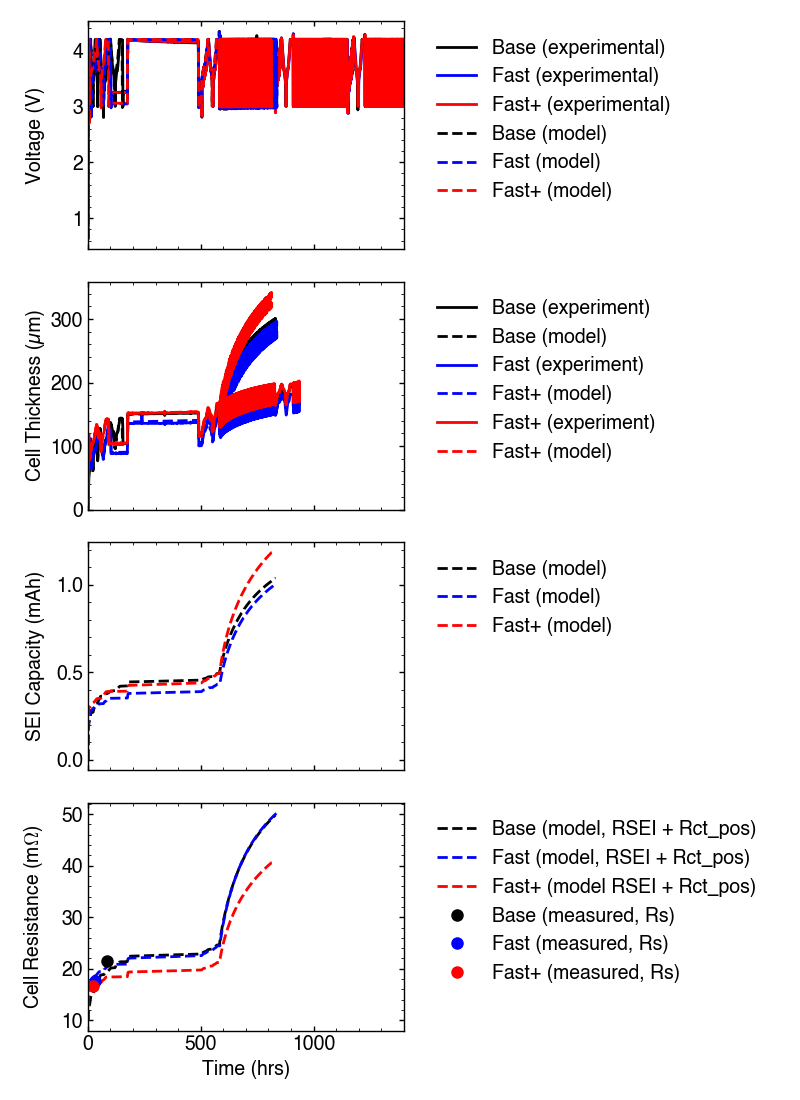

In [ ]:
%matplotlib widget

XMAX = 1400;

fig, axs = plt.subplots(4, 1, figsize=(8,11), sharex=True)

# First subplot - Voltage
axs[0].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='k', label='Base (experimental)')
axs[0].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='b', label='Fast (experimental)')
axs[0].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label='Fast+ (experimental)')
axs[0].plot(df_sim1['t']/3600, df_sim1['vt'], color='k', ls='--', label='Base (model)')
axs[0].plot(df_sim2['t']/3600, df_sim2['vt'], color='b', ls='--', label='Fast (model)')
axs[0].plot(df_sim3['t']/3600, df_sim3['vt'], color='r', ls='--', label='Fast+ (model)')
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[0].set_ylabel('Voltage (V)')
axs[0].grid(False)

# axs[1].plot(df_sim1['t']/3600, df_sim1['delta_sei1']*1e6, color='k', label='Base (EC)', ls='--')
axs[1].plot(expt1['daq_time']/3600, expt1['daq_strain'], color='k', label='Base (experiment)', ls='-')
axs[1].plot(df_sim1['t']/3600, df_sim1['expansion']*1e6, color='k', label='Base (model)', ls='--')
# axs[1].plot(df_sim1['t']/3600, df_sim1['expansion_irrev']*1e6, color='k', label='', ls=':')
# axs[1].plot(df_sim2['t']/3600, df_sim2['delta_sei1']*1e6, color='b', label='Fast (EC)', ls='--')
axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], color='b', label='Fast (experiment)', ls='-')
axs[1].plot(df_sim2['t']/3600, df_sim2['expansion']*1e6, color='b', label='Fast+ (model)', ls='--')
# axs[1].plot(df_sim2['t']/3600, df_sim2['expansion_irrev']*1e6, color='b', label='', ls=':')
# axs[1].plot(df_sim3['t']/3600, df_sim3['delta_sei1']*1e6, color='r', label='Fast+ (EC)', ls='--')
axs[1].plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label='Fast+ (experiment)', ls='-')
axs[1].plot(df_sim3['t']/3600, df_sim3['expansion']*1e6, color='r', label='Fast+ (model)', ls='--')
# axs[1].plot(df_sim3['t']/3600, df_sim3['expansion_irrev']*1e6, color='r', label='', ls=':')
axs[1].set_ylabel(r'Cell Thickness (µm)')
axs[1].set_ylim(bottom=0)
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].grid(False)

# Capacity
axs[2].plot(df_sim1['t']/3600, df_sim1['q_sei'], color='k', label='Base (model)', ls='--')
axs[2].plot(df_sim2['t']/3600, df_sim2['q_sei'], color='b', label='Fast (model)', ls='--')
axs[2].plot(df_sim3['t']/3600, df_sim3['q_sei'], color='r', label='Fast+ (model)', ls='--')
axs[2].grid(False)
axs[2].set_ylabel(r'SEI Capacity (mAh)')
axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

gamma = 0.3;
# Second subplot - SEI resistance
# axs[2].plot(df_sim1['t']/3600, df_sim1['R_sei1']*1000, color='k', label='Base (EC)', ls='--')
axs[3].plot(df_sim1['t']/3600, gamma*df_sim1['R_sei']*1000 + 10, color='k', label='Base (model, RSEI + Rct_pos)', ls='--')
# axs[2].plot(df_sim2['t']/3600, df_sim2['R_sei1']*1000, color='b', ls='--', label='Fast (EC)')
axs[3].plot(df_sim2['t']/3600, gamma*df_sim2['R_sei']*1000 + 10, color='b', ls='--', label='Fast (model, RSEI + Rct_pos)')
# axs[2].plot(df_sim3['t']/3600, df_sim3['R_sei1']*1000, color='r', ls='--', label='Fast+ (EC)')
axs[3].plot(df_sim3['t']/3600, gamma*df_sim3['R_sei']*1000 + 10, color='r', ls='--', label='Fast+ (model RSEI + Rct_pos)')
axs[3].set_ylabel(r'Cell Resistance (m$\Omega$)')
axs[3].set_xlim((0,XMAX))
axs[3].set_xlabel('Time (hrs)')
axs[3].grid(False)

rs_meas1_base = 21.5e-3 
rs_meas1_fast = 17.7e-3
rs_meas1_fast_plus = 16.6e-3 

t_hppc1_base = 69.39*3600
t_hppc1_fast = 16.17*3600
t_hppc1_fast_plus = 7.465*3600
rs_meas1_time_base = t_hppc1_base + 54000
rs_meas1_time_fast = t_hppc1_fast + 54000
rs_meas1_time_fast_plus = t_hppc1_fast_plus + 54000

axs[3].plot(rs_meas1_time_base/3600, rs_meas1_base*1000, 'ko', markersize=8, label='Base (measured, Rs)')
axs[3].plot(rs_meas1_time_fast/3600, rs_meas1_fast*1000, 'bo', markersize=8, label='Fast (measured, Rs)')
axs[3].plot(rs_meas1_time_fast_plus/3600, rs_meas1_fast_plus*1000, 'ro', markersize=8, label='Fast+ (measured, Rs)')
axs[3].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

rs_meas2_time = 505.23 * 3600 + 5e4
rs_meas2_base = 0.0375
rs_meas2_fast = 0.0366
rs_meas2_fast_plus = 0.0366

axs[3].plot(rs_meas2_time/3600, rs_meas2_base*1000, 'ko', markersize=8, label='')
axs[3].plot(rs_meas2_time/3600, rs_meas2_fast*1000, 'bo', markersize=8, label=')')
axs[3].plot(rs_meas2_time/3600, rs_meas2_fast_plus*1000, 'ro', markersize=8, label='')
axs[3].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()

# Process HPPC experimental data

In [9]:
# Define the step indices for the HPPC sequence
si1_hppc = [11, 12, 13, 14, 15, 16, 17]
si2_hppc = [13, 14, 15, 16, 17, 18, 19]
si3_hppc = [13, 14, 15, 16, 17, 18, 19]

si1_hppc = [12, 13, 14, 15, 16, 17]
si2_hppc = [14, 15, 16, 17, 18, 19]
si3_hppc = [14, 15, 16, 17, 18, 19]


In [10]:
def calculate_resistance_estimates(Vmeas, Imeas, time):

    den = - (Imeas[0:-2] - Imeas[1:-1])
    dt = time[0:-2] - time[1:-1]
    num = Vmeas[1:-1] - Vmeas[0:-2]
    idx = np.where((den < -1.5) & (np.abs(dt) < 10))[0]
    Rs_estimate = num[idx]/den[idx]

    return Rs_estimate, idx

## First HPPC

In [11]:
# Subset df1, df3, and df4 using si1_hppc, si2_hppc, and si3_hppc to filter on 'Step Index'
df1_one = df1[df1['Timestamp'] < pd.to_datetime('2022-09-15')]
df3_one = df3[df3['Timestamp'] < pd.to_datetime('2022-09-15')]
df4_one = df4[df4['Timestamp'] < pd.to_datetime('2022-09-15')]

subset_df1 = df1_one[df1_one['Step Index'].isin(si1_hppc)]
subset_df3 = df3_one[df3_one['Step Index'].isin(si2_hppc)]
subset_df4 = df4_one[df4_one['Step Index'].isin(si3_hppc)]

subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
subset_df4['Time (s)'] = (subset_df4['Timestamp'] - subset_df4['Timestamp'].iloc[0]).dt.total_seconds()

# Define a 0.1s grid for interpolation
time_grid = np.arange(0, max(subset_df1['Time (s)'].max(), subset_df3['Time (s)'].max(), subset_df4['Time (s)'].max()), 0.1)

# Interpolate for subset_df1
interp_voltage1 = interp1d(subset_df1['Time (s)'], subset_df1['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current1 = interp1d(subset_df1['Time (s)'], subset_df1['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp1 = time_grid
voltage_interp1 = interp_voltage1(time_interp1)
current_interp1 = interp_current1(time_interp1)

# Interpolate for subset_df3
interp_voltage3 = interp1d(subset_df3['Time (s)'], subset_df3['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current3 = interp1d(subset_df3['Time (s)'], subset_df3['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp3 = time_grid
voltage_interp3 = interp_voltage3(time_interp3)
current_interp3 = interp_current3(time_interp3)

# Interpolate for subset_df4
interp_voltage4 = interp1d(subset_df4['Time (s)'], subset_df4['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current4 = interp1d(subset_df4['Time (s)'], subset_df4['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp4 = time_grid
voltage_interp4 = interp_voltage4(time_interp4)
current_interp4 = interp_current4(time_interp4)


/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_10753/3483031655.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_10753/3483031655.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn

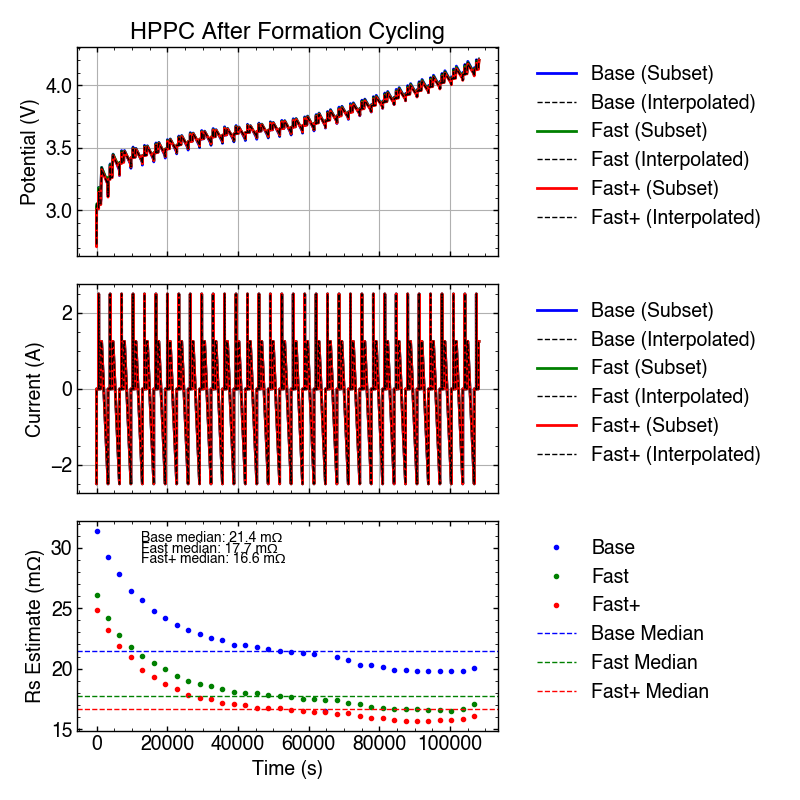

In [12]:
Rs_estimate1, idx1 = calculate_resistance_estimates(subset_df1['Potential (V)'].values, subset_df1['Current (A)'].values, subset_df1['Time (s)'].values)
Rs_estimate3, idx3 = calculate_resistance_estimates(subset_df3['Potential (V)'].values, subset_df3['Current (A)'].values, subset_df3['Time (s)'].values)
Rs_estimate4, idx4 = calculate_resistance_estimates(subset_df4['Potential (V)'].values, subset_df4['Current (A)'].values, subset_df4['Time (s)'].values)

fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axs[0].set_title('HPPC After Formation Cycling')
axs[0].plot(subset_df1['Time (s)'], subset_df1['Potential (V)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[0].plot(time_interp1, voltage_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df3['Time (s)'], subset_df3['Potential (V)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[0].plot(time_interp3, voltage_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df4['Time (s)'], subset_df4['Potential (V)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[0].plot(time_interp4, voltage_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].set_ylabel('Potential (V)')
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Second subplot for Current
axs[1].plot(subset_df1['Time (s)'], subset_df1['Current (A)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[1].plot(time_interp1, current_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df3['Time (s)'], subset_df3['Current (A)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[1].plot(time_interp3, current_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df4['Time (s)'], subset_df4['Current (A)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[1].plot(time_interp4, current_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].set_ylabel('Current (A)')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

trs1 = subset_df1['Time (s)'].iloc[idx1]
trs3 = subset_df3['Time (s)'].iloc[idx3]
trs4 = subset_df4['Time (s)'].iloc[idx4]
axs[2].plot(trs1 - trs1.iloc[0], Rs_estimate1*1e3, label='Base', color='blue', marker='o', markersize=3, linestyle='None')
axs[2].plot(trs3 - trs3.iloc[0], Rs_estimate3*1e3, label='Fast', color='green', marker='o', markersize=3, linestyle='None')
axs[2].plot(trs4 - trs4.iloc[0], Rs_estimate4*1e3, label='Fast+', color='red', marker='o', markersize=3, linestyle='None')
axs[2].axhline(np.nanmedian(Rs_estimate1)*1e3, color='blue', linestyle='--', linewidth=1, label='Base Median')
axs[2].axhline(np.nanmedian(Rs_estimate3)*1e3, color='green', linestyle='--', linewidth=1, label='Fast Median')
axs[2].axhline(np.nanmedian(Rs_estimate4)*1e3, color='red', linestyle='--', linewidth=1, label='Fast+ Median')
axs[2].annotate(f'Base median: {np.nanmedian(Rs_estimate1*1e3):.1f} mΩ', 
                xy=(0.15, 0.90), xycoords='axes fraction', fontsize=10)
axs[2].annotate(f'Fast median: {np.nanmedian(Rs_estimate3*1e3):.1f} mΩ',
                xy=(0.15, 0.85), xycoords='axes fraction', fontsize=10)
axs[2].annotate(f'Fast+ median: {np.nanmedian(Rs_estimate4*1e3):.1f} mΩ',
                xy=(0.15, 0.80), xycoords='axes fraction', fontsize=10)
axs[2].set_xlabel('Time (s)')
axs[2].grid(False)
axs[2].set_ylabel('Rs Estimate (mΩ)')
axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

## Second HPPC (after formation aging)

In [13]:
si1_hppc = [12, 13, 14, 15, 16, 17]
si2_hppc = [14, 15, 16, 17, 18, 19]
si3_hppc = [14, 15, 16, 17, 18, 19]

# Subset df1, df3, and df4 using si1_hppc, si2_hppc, and si3_hppc to filter on 'Step Index'
df1_one = df1[(df1['Timestamp'] > pd.to_datetime('2022-09-15')) & (df1['Timestamp'] < pd.to_datetime('2022-10-01'))]
df3_one = df3[(df3['Timestamp'] > pd.to_datetime('2022-09-15')) & (df3['Timestamp'] < pd.to_datetime('2022-10-01'))]
df4_one = df4[(df4['Timestamp'] > pd.to_datetime('2022-09-15')) & (df4['Timestamp'] < pd.to_datetime('2022-10-01'))]

subset_df1 = df1_one[df1_one['Step Index'].isin(si1_hppc)]
subset_df3 = df3_one[df3_one['Step Index'].isin(si2_hppc)]
subset_df4 = df4_one[df4_one['Step Index'].isin(si3_hppc)]

subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
subset_df4['Time (s)'] = (subset_df4['Timestamp'] - subset_df4['Timestamp'].iloc[0]).dt.total_seconds()

# Define a 0.1s grid for interpolation
time_grid = np.arange(0, max(subset_df1['Time (s)'].max(), subset_df3['Time (s)'].max(), subset_df4['Time (s)'].max()), 0.1)

# Interpolate for subset_df1
interp_voltage1 = interp1d(subset_df1['Time (s)'], subset_df1['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current1 = interp1d(subset_df1['Time (s)'], subset_df1['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp1 = time_grid
voltage_interp1 = interp_voltage1(time_interp1)
current_interp1 = interp_current1(time_interp1)

# Interpolate for subset_df3
interp_voltage3 = interp1d(subset_df3['Time (s)'], subset_df3['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current3 = interp1d(subset_df3['Time (s)'], subset_df3['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp3 = time_grid
voltage_interp3 = interp_voltage3(time_interp3)
current_interp3 = interp_current3(time_interp3)

# Interpolate for subset_df4
interp_voltage4 = interp1d(subset_df4['Time (s)'], subset_df4['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current4 = interp1d(subset_df4['Time (s)'], subset_df4['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp4 = time_grid
voltage_interp4 = interp_voltage4(time_interp4)
current_interp4 = interp_current4(time_interp4)


/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_10753/3191092511.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_10753/3191092511.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn

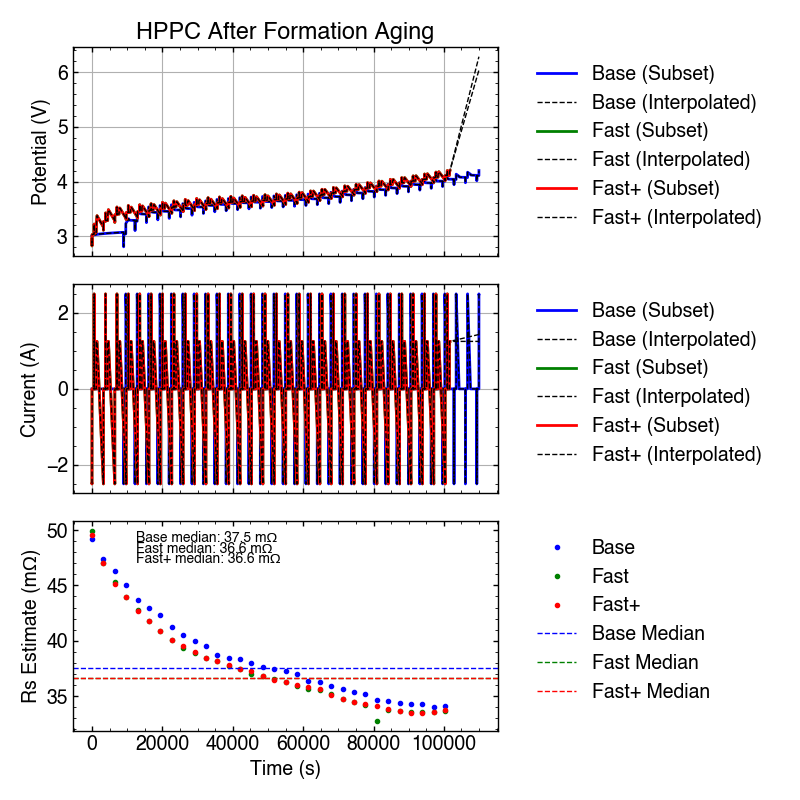

In [15]:
%matplotlib widget

Rs_estimate1, idx1 = calculate_resistance_estimates(subset_df1['Potential (V)'].values, subset_df1['Current (A)'].values, subset_df1['Time (s)'].values)
Rs_estimate3, idx3 = calculate_resistance_estimates(subset_df3['Potential (V)'].values, subset_df3['Current (A)'].values, subset_df3['Time (s)'].values)
Rs_estimate4, idx4 = calculate_resistance_estimates(subset_df4['Potential (V)'].values, subset_df4['Current (A)'].values, subset_df4['Time (s)'].values)

plt.close('all')  

fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axs[0].set_title('HPPC After Formation Aging')
axs[0].plot(subset_df1['Time (s)'], subset_df1['Potential (V)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[0].plot(time_interp1, voltage_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df3['Time (s)'], subset_df3['Potential (V)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[0].plot(time_interp3, voltage_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df4['Time (s)'], subset_df4['Potential (V)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[0].plot(time_interp4, voltage_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].set_ylabel('Potential (V)')
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Second subplot for Current
axs[1].plot(subset_df1['Time (s)'], subset_df1['Current (A)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[1].plot(time_interp1, current_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df3['Time (s)'], subset_df3['Current (A)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[1].plot(time_interp3, current_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df4['Time (s)'], subset_df4['Current (A)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[1].plot(time_interp4, current_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].set_ylabel('Current (A)')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

trs1 = subset_df1['Time (s)'].iloc[idx1]
trs3 = subset_df3['Time (s)'].iloc[idx3]
trs4 = subset_df4['Time (s)'].iloc[idx4]
axs[2].plot(trs1 - trs1.iloc[0], Rs_estimate1*1e3, label='Base', color='blue', marker='o', markersize=3, linestyle='None')
axs[2].plot(trs3 - trs3.iloc[0], Rs_estimate3*1e3, label='Fast', color='green', marker='o', markersize=3, linestyle='None')
axs[2].plot(trs4 - trs4.iloc[0], Rs_estimate4*1e3, label='Fast+', color='red', marker='o', markersize=3, linestyle='None')
axs[2].axhline(np.nanmedian(Rs_estimate1)*1e3, color='blue', linestyle='--', linewidth=1, label='Base Median')
axs[2].axhline(np.nanmedian(Rs_estimate3)*1e3, color='green', linestyle='--', linewidth=1, label='Fast Median')
axs[2].axhline(np.nanmedian(Rs_estimate4)*1e3, color='red', linestyle='--', linewidth=1, label='Fast+ Median')
axs[2].annotate(f'Base median: {np.nanmedian(Rs_estimate1*1e3):.1f} mΩ', 
                xy=(0.15, 0.90), xycoords='axes fraction', fontsize=10)
axs[2].annotate(f'Fast median: {np.nanmedian(Rs_estimate3*1e3):.1f} mΩ',
                xy=(0.15, 0.85), xycoords='axes fraction', fontsize=10)
axs[2].annotate(f'Fast+ median: {np.nanmedian(Rs_estimate4*1e3):.1f} mΩ',
                xy=(0.15, 0.80), xycoords='axes fraction', fontsize=10)
axs[2].set_xlabel('Time (s)')
axs[2].grid(False)
axs[2].set_ylabel('Rs Estimate (mΩ)')
axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# axs[2].set_xlim((0, 5000))?

plt.show()

# Manually extract the capacities from inspecting the plots

In [ ]:
f1_capd1 = 2.527
f2_capd1 = 2.540
f3_capd1 = 2.536
f1_capd2 = 2.445
f2_capd2 = 2.461
f3_capd2 = 2.461
f1_capd3 = 2.275
f2_capd3 = 2.315
f3_capd3 = 2.318


# Summarize the results

In [ ]:
data = {
    'Q1 [Ah]': [f1_capd1, f2_capd1, f3_capd1],
    'Q2 [Ah]': [f1_capd2, f2_capd2, f3_capd2],
    'Q3 [Ah]': [f1_capd3, f2_capd3, f3_capd3],
    'Rs [Ohms]': [np.nanmedian(Rs_estimate1), np.nanmedian(Rs_estimate3), np.nanmedian(Rs_estimate4)]
}
labels = ['Base', 'Fast', 'Fast+']

df_summary = pd.DataFrame(data, index=labels)
df_summary

# Now take a closer look at all of the data

Including the cycling data!

In [ ]:
expt1, df1 = ioutils.fetch_experimental_data(152064, to_include_cycling=True)
expt3, df3 = ioutils.fetch_experimental_data(152071, to_include_cycling=True)
expt4, df4 = ioutils.fetch_experimental_data(152098, to_include_cycling=True)

In [ ]:
fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# First subplot
axs[0].plot(df1['Timestamp'], df1['Potential (V)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[0].plot(df3['Timestamp'], df3['Potential (V)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[0].plot(df4['Timestamp'], df4['Potential (V)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[0].set_ylabel('Potential (V)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

# Second subplot
axs[1].plot(df1['Timestamp'], df1['Discharge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[1].plot(df3['Timestamp'], df3['Discharge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[1].plot(df4['Timestamp'], df4['Discharge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[1].set_ylabel('Dis. Capacity (Ah)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

# Third subplot
axs[2].plot(df1['Timestamp'], df1['Charge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[2].plot(df3['Timestamp'], df3['Charge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[2].plot(df4['Timestamp'], df4['Charge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[2].set_ylabel('Chg. Capacity (Ah)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend()

# Fourth subplot
axs[3].plot(df1['Timestamp'], df1['Step Index'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[3].plot(df3['Timestamp'], df3['Step Index'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[3].plot(df4['Timestamp'], df4['Step Index'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[3].set_ylabel('Step Index')
axs[3].set_xlabel('Timestamp')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend()


# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()


# Cycle life

In [ ]:
NOM_CAP = 2.5

df1_agg = df1.groupby('Cycle Number')['Discharge Capacity (Ah)'].max()
df3_agg = df3.groupby('Cycle Number')['Discharge Capacity (Ah)'].max()
df4_agg = df4.groupby('Cycle Number')['Discharge Capacity (Ah)'].max()

df1_agg_cumsum = df1_agg.cumsum()/NOM_CAP
df3_agg_cumsum = df3_agg.cumsum()/NOM_CAP
df4_agg_cumsum = df4_agg.cumsum()/NOM_CAP

df1_agg[df1_agg.values < 1] = np.nan
df3_agg[df3_agg.values < 1] = np.nan
df4_agg[df4_agg.values < 1] = np.nan

fig, axs = plt.subplots(1, 1, figsize=(10, 4), sharex=True)

# Aggregate and plot for df1
axs.plot(df1_agg_cumsum.values, df1_agg.values, label='Base', color='blue', marker='o', linestyle='')
axs.plot(df3_agg_cumsum.values, df3_agg.values, label='Fast', color='green', marker='o', linestyle='')
axs.plot(df4_agg_cumsum.values, df4_agg.values, label='Fast+', color='red', marker='o', linestyle='')
axs.set_ylabel('Discharge Capacity (Ah)')
axs.set_xlabel('EFCs (-)')
axs.set_title('Cumulative Discharge Capacity')
axs.grid(True)
axs.legend()

plt.tight_layout()
plt.show()

# Coulombic efficiency during formation

In [ ]:
df1lim = df1[df1['Cycle Number'] <= 3]
df1lim = df1lim[df1lim['Timestamp'] < '2022-09-06 00:00:00']

df1lim_agg = df1lim.groupby('Cycle Number').agg({'Charge Capacity (Ah)': 'max', 'Discharge Capacity (Ah)': 'max'})
df1lim_agg['Coulombic Efficiency'] = df1lim_agg['Discharge Capacity (Ah)'] / df1lim_agg['Charge Capacity (Ah)']
print(df1lim_agg)

fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# First subplot: Potential (V) vs. Timestamp
axs[0].plot(df1lim['Timestamp'], df1lim['Potential (V)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[0].set_ylabel('Potential (V)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

# Second subplot: Discharge Capacity (Ah) vs. Timestamp
axs[1].plot(df1lim['Timestamp'], df1lim['Discharge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[1].set_ylabel('Dis. Capacity (Ah)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

# Third subplot: Charge Capacity (Ah) vs. Timestamp
axs[2].plot(df1lim['Timestamp'], df1lim['Charge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[2].set_ylabel('Chg. Capacity (Ah)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend()

# Fourth subplot: Step Index vs. Timestamp
axs[3].plot(df1lim['Timestamp'], df1lim['Cycle Number'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[3].set_ylabel('Cycle Index')
axs[3].set_xlabel('Timestamp')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend()

# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()

# Expansion Data

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(expt1['daq_time'], expt1['daq_strain'], label='Base')
ax.plot(expt3['daq_time'], expt3['daq_strain'], label='Fast')
ax.plot(expt4['daq_time'], expt4['daq_strain'], label='Fast+')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Strain (µm)')
ax.set_title('Expansion Data')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(12, 8), sharex=True)

axs[0,0].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], label='Baseline (Cell 1)', color='black')
axs[0,0].plot(expt2['arbin_time']/3600, expt2['arbin_voltage'], label='Baseline (Cell 2)', color='black', ls=':')
axs[0,0].grid(False)
axs[0,0].legend()
axs[0,0].set_ylabel('Potential (V)')

axs[1,0].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], label='Fast', color='blue')
axs[1,0].grid(False)
axs[1,0].legend()
axs[1,0].set_ylabel('Potential (V)')

axs[2,0].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], label='Fast+', color='red')
axs[2,0].set_ylabel('Potential (V)')
axs[2,0].legend()
axs[2,0].grid(False)

axs[2,0].set_xlim((-0.1, 600))
axs[2,0].set_xlabel('Time (hrs)')

# Second subplot: Strain vs. Time
axs[0,1].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Baseline (Cell 1)', color='black')
axs[0,1].plot(expt2['daq_time']/3600, expt2['daq_strain'], label='Baseline (Cell 2)', color='black', ls=':')
axs[0,1].grid(False)
axs[0,1].legend()
axs[0,1].set_ylabel('Strain (µm)')

axs[1,1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast', color='blue')
axs[1,1].grid(False)
axs[1,1].legend()
axs[1,1].set_ylabel('Strain (µm)')

axs[2,1].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+', color='red')
axs[2,1].set_ylabel('Strain (µm)')
axs[2,1].legend()
axs[2,1].grid(False)
axs[2,1].set_xlabel('Time (hrs)')

axs[2,1].set_xlim((-0.1, 450))

plt.tight_layout()
plt.show()

In [ ]:
from src import cellsim as cellsim

%autoreload
Ichg = 2.5/10  # A
Idch = -2.5/10 # A
Icv = 2.5/20   # A

vmax = 4.2
vmin = 3.0

cell = cellsim.Cell()
cell.load_config('params/default.yaml')
tag = cell.get_tag()

# sim = cellsim.Simulation(cell, 520*3600)
sim1 = cellsim.Simulation(cell, 70*24*3600)

# Formation
sim1.run_rest(1, rest_time_hrs=0.5)
sim1.run_chg_cccv(2, 2.5/10, 2.5/20, 4.2)
sim1.run_rest(2, rest_time_hrs=1/6) 
sim1.run_dch_cccv(2, -2.5/10, -2.5/10, 3.0)
sim1.run_rest(2, rest_time_hrs=1/6) 
sim1.run_chg_cccv(3, 2.5/10, 2.5/20, 4.2)
sim1.run_rest(3, rest_time_hrs=1/6) 
sim1.run_dch_cccv(3, -2.5/10, -2.5/10, 3.0)
sim1.run_rest(3, rest_time_hrs=1/6) 
sim1.run_chg_cccv(4, 2.5/10, 2.5/20, 4.2)
sim1.run_rest(4, rest_time_hrs=1/6) 
sim1.run_dch_cccv(4, -2.5/10, 0.05, 3.0)
sim1.run_rest(4, rest_time_hrs=1/6) 
sim1.run_dch_cccv(4, -2.5/10, 0.05, 3.0)
sim1.run_rest(4, rest_time_hrs=6)

# RPT
sim1.run_chg_cccv(5, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(5, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(6, +2.5/20, Icv, vmax)
sim1.run_rest(6, rest_time_hrs=12)
sim1.run_dch_cccv(6, -2.5/2, -2.5/2, vmin)
sim1.run_rest(6, rest_time_hrs=20)

# Formation Aging
sim1.run_chg_cccv(7, 2.5/2, 0.05, vmax)
sim1.run_rest(7, rest_time_hrs=13*24) # 13 days rest
sim1.run_dch_cccv(7, -2.5/2, -2.5/2, vmin)
sim1.run_rest(7, rest_time_hrs=12) # 12 hours rest

# RPT
sim1.run_chg_cccv(8, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(8, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(8, +2.5/20, Icv, vmax)
sim1.run_rest(    9, rest_time_hrs=12)
sim1.run_dch_cccv(9, -2.5/2, -2.5/2, vmin)

# Cycling
cycles_to_rpt = 100
for i in np.arange(10, 10 + cycles_to_rpt + 1):
    sim1.run_chg_cccv(i, 2.5, 0.125, vmax)
    sim1.run_rest(i, rest_time_hrs=1/6)
    sim1.run_dch_cccv(i, -2.5, -2.5, vmin)
    sim1.run_rest(i, rest_time_hrs=1/6)

# RPT
sim1.run_chg_cccv(111, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(111, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(111, +2.5/20, Icv, vmax)
sim1.run_rest(112, rest_time_hrs=12)
sim1.run_dch_cccv(112, -2.5/2, -2.5/2, vmin)

# Cycling
for i in np.arange(113, 113 + cycles_to_rpt + 1):
    sim1.run_chg_cccv(i, 2.5, 0.125, vmax)
    sim1.run_rest(i, rest_time_hrs=1/6)
    sim1.run_dch_cccv(i, -2.5, -2.5, vmin)
    sim1.run_rest(i, rest_time_hrs=1/6)

# RPT
sim1.run_chg_cccv(214, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(214, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(215, +2.5/20, Icv, vmax)
sim1.run_rest(    215, rest_time_hrs=12)
sim1.run_dch_cccv(215, -2.5/2, -2.5/2, vmin)

# Cycling
for i in np.arange(216, 216 + cycles_to_rpt + 1):
    sim1.run_chg_cccv(i, 2.5, 0.125, vmax)
    sim1.run_rest(i, rest_time_hrs=1/6)
    sim1.run_dch_cccv(i, -2.5, -2.5, vmin)
    sim1.run_rest(i, rest_time_hrs=1/6)

# RPT
sim1.run_chg_cccv(317, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(317, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(318, +2.5/20, Icv, vmax)
sim1.run_rest(    318, rest_time_hrs=12)
sim1.run_dch_cccv(318, -2.5/2, -2.5/2, vmin)

df_sim1 = sim1.get_results()

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# First subplot: Time vs Voltage
axs[0].plot(df_sim1['t']/3600/24, df_sim1['vt'], label='Simulated', color='blue')
axs[0].plot(expt1['arbin_time']/3600/24, expt1['arbin_voltage'], label='Measured', color='black')
axs[0].set_ylabel('Voltage (V)')
axs[0].grid(False)

axs[1].plot(df_sim1['t']/3600/24, df_sim1['i_app'], label='Simulated', color='blue')
axs[1].plot(expt1['arbin_time']/3600/24, expt1['arbin_current'], label='Measured', color='black')
axs[1].set_ylabel('Current (A)')
axs[1].grid(False)

# Second subplot: Time vs Expansion
axs[2].plot(df_sim1['t']/3600/24, 1e6*df_sim1['expansion'], label='Simulated', color='blue')
axs[2].plot(expt1['daq_time']/3600/24, expt1['daq_strain'], label='Measured', color='black')
axs[2].set_ylabel('Strain (µm)')
axs[2].grid(False)

# Third subplot: Time vs R_sei
axs[3].plot(df_sim1['t']/3600/24, 1e3*df_sim1['R_sei'], label='Simulated R_sei', color='blue')
axs[3].set_xlabel('Time (days)')
axs[3].set_ylabel('R (mOhm)')
axs[3].grid(False)

plt.tight_layout()
plt.show()